In [6]:
import matplotlib.pyplot as plt
# Importation de matplotlib.
# Cette bibliothèque sert à créer des graphiques
# afin de visualiser les données et les résultats du modèle.
import numpy as np
# Importation de la bibliothèque numpy.
# Elle permet de manipuler facilement les données numériques
# sous forme de tableaux et de matrices.
# C’est une bibliothèque essentielle dans le machine learning
# car elle facilite les calculs mathématiques rapides.

Prédictions finales : [0 0 0 1 1 1]
Accuracy : 1.0


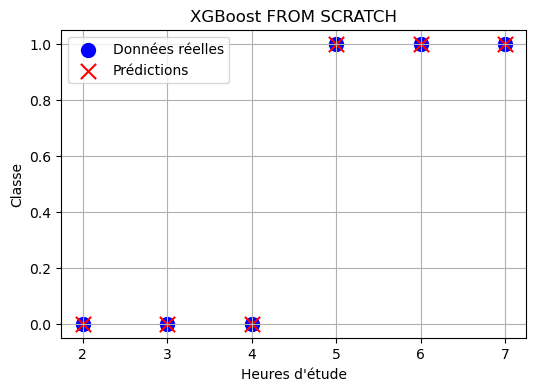

In [11]:
#L'algorithme XGBoost (Apprentissage supervise) from scratch


# ================================
# 1. Création du dataset
# ================================

X = np.array([
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 8]
])
# X représente les variables explicatives (features).

# Chaque ligne correspond à un étudiant.

# colonne 1 :
# nombre d’heures d’étude

# colonne 2 :
# niveau de participation en classe

# Ces informations seront utilisées
# pour prédire si l’étudiant réussit ou non.

y = np.array([0, 0, 0, 1, 1, 1])
# y représente les classes réelles :

# 0 = échec
# 1 = réussite

# Le modèle doit apprendre la relation
# entre les variables X et les résultats y.

# ================================
# 2. Initialisation des prédictions
# ================================

y_pred = np.full(len(y), np.mean(y))
# XGBoost commence toujours
# par une prédiction simple.

# Ici on initialise toutes les prédictions
# avec la moyenne des valeurs de y.

# np.full crée un tableau rempli
# avec la même valeur.

# ================================
# 3. Paramètres du modèle
# ================================

learning_rate = 0.3
# Le learning rate contrôle
# la vitesse d’apprentissage.

# petite valeur :
# apprentissage plus lent mais plus stable

# grande valeur :
# apprentissage rapide mais moins stable

n_estimators = 5
# Nombre d’itérations de boosting.

# Chaque itération ajoute
# un nouveau petit modèle
# qui corrige les erreurs précédentes.

# ================================
# 4. Phase d’apprentissage
# ================================

for i in range(n_estimators):

    # ----------------------------
    # 4.1 Calcul des erreurs
    # ----------------------------

    residuals = y - y_pred
    # residuals = erreurs du modèle actuel
    
    # XGBoost cherche toujours
    # à corriger ces erreurs.

    # ----------------------------
    # 4.2 Création d’un mini arbre
    # ----------------------------

    threshold = np.mean(X[:,0])
    # seuil simple basé sur la moyenne
    # des heures d’étude

    stump_pred = np.where(X[:,0] <= threshold, 0, 1)
    # Petit arbre de décision :
    
    # si heures d’étude <= seuil :
    # prédiction = 0
    
    # sinon :
    # prédiction = 1

    # ----------------------------
    # 4.3 Mise à jour du modèle
    # ----------------------------

    y_pred = y_pred + learning_rate * (stump_pred - y_pred)
    # Mise à jour progressive des prédictions.
    
    # Le modèle corrige petit à petit
    # ses erreurs précédentes.
    
    # C’est le principe principal du boosting.

# ================================
# 5. Transformation finale
# ================================

final_predictions = (y_pred >= 0.5).astype(int)
# Conversion des probabilités
# vers des classes finales :

# >= 0.5 → classe 1
# < 0.5 → classe 0

print("Prédictions finales :", final_predictions)

# ================================
# 6. Accuracy simple
# ================================

accuracy = np.mean(final_predictions == y)
# Calcul manuel de l’accuracy.

# On compare les prédictions
# avec les vraies classes.

# np.mean calcule le pourcentage
# de bonnes réponses.

print("Accuracy :", accuracy)

# ================================
# 7. Graphe simple
# ================================

plt.figure(figsize=(6,4))
# Création de la figure.

plt.scatter(X[:,0], y, color="blue", s=100, label="Données réelles")
# Affichage des vraies données.

# X[:,0] :
# heures d’étude

# y :
# classes réelles

plt.scatter(X[:,0], final_predictions,
            color="red",
            marker="x",
            s=120,
            label="Prédictions")
# Affichage des prédictions du modèle.

# marker="x" :
# affichage sous forme de croix rouges

plt.xlabel("Heures d'étude")
# Nom de l’axe horizontal.

plt.ylabel("Classe")
# Nom de l’axe vertical.

plt.title("XGBoost FROM SCRATCH")
# Titre du graphique.

plt.legend()
# Affichage de la légende.

plt.grid(True)
# Ajout d’une grille
# pour améliorer la lisibilité.

plt.show()
# Affichage final du graphique.



Clusters : [ 0  0  0  1  1 -1]


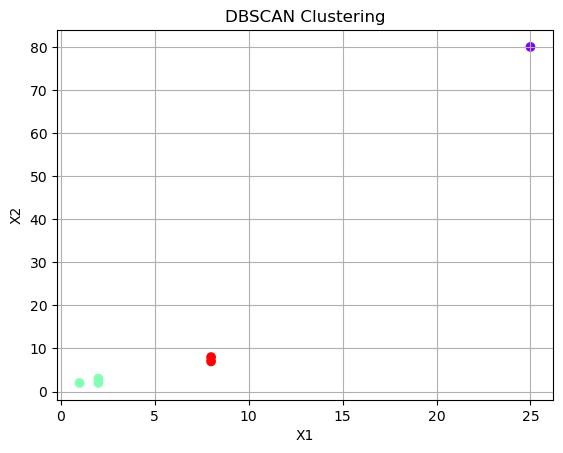

In [8]:
#DBSCAN (apprentissage non supervise) from scratch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
# Importation de l’algorithme DBSCAN.
# DBSCAN est un algorithme de clustering.
# Il regroupe automatiquement les données similaires
# sans utiliser de classes prédéfinies.

# ================================
# 1. Dataset
# ================================

X = np.array([
    [1, 2],
    [2, 2],
    [2, 3],
    [8, 7],
    [8, 8],
    [25, 80]
])
# Chaque ligne représente un point dans un espace 2D.
# Les points proches vont former des clusters.
# Le dernier point est très éloigné :
# il sera probablement considéré comme du bruit (noise).

# ================================
# 2. Création du modèle DBSCAN
# ================================

model = DBSCAN(eps=2, min_samples=2)
# eps :
# distance maximale entre deux voisins.
# Si deux points sont proches selon cette distance,
# ils peuvent appartenir au même cluster.

# min_samples :
# nombre minimal de voisins nécessaires
# pour former un cluster valide.

labels = model.fit_predict(X)
# fit_predict :
# - le modèle apprend automatiquement
# - puis il attribue un cluster à chaque point

print("Clusters :", labels)
# Affichage des clusters trouvés.
# -1 signifie généralement un bruit (noise).

# ================================
# 3. Visualisation des clusters
# ================================

plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
# Affichage des points.
# Chaque cluster possède une couleur différente.

plt.title("DBSCAN Clustering")
plt.xlabel("X1")
plt.ylabel("X2")

plt.grid(True)
plt.show()

Dataset original :
[[2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]
 [6 7 8]]

Données centrées :
[[-2. -2. -2.]
 [-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]
 [ 2.  2.  2.]]

Matrice de covariance :
[[2.5 2.5 2.5]
 [2.5 2.5 2.5]
 [2.5 2.5 2.5]]

Valeurs propres :
[ 7.50000000e+00 -2.02308738e-16 -1.23259516e-32]

Vecteurs propres :
[[ 5.77350269e-01  7.09975853e-01  1.43668215e-17]
 [ 5.77350269e-01 -7.04202354e-01 -7.07106781e-01]
 [ 5.77350269e-01 -5.77349958e-03  7.07106781e-01]]

Composantes principales :
[[ 5.77350269e-01  1.43668215e-17]
 [ 5.77350269e-01 -7.07106781e-01]
 [ 5.77350269e-01  7.07106781e-01]]

Données réduites :
[[-3.46410162  0.        ]
 [-1.73205081  0.        ]
 [ 0.          0.        ]
 [ 1.73205081  0.        ]
 [ 3.46410162  0.        ]]


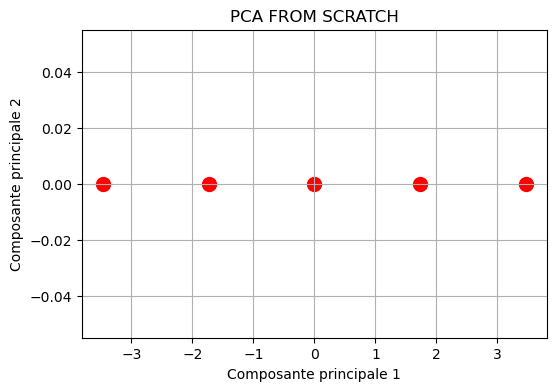

In [13]:
#L'algorithme PCA (Réduction de dimension)  FROM SCRATCH 
import numpy as np
import matplotlib.pyplot as plt


# ================================
# 1. Dataset
# ================================

X = np.array([
    [2, 3, 4],
    [3, 4, 5],
    [4, 5, 6],
    [5, 6, 7],
    [6, 7, 8]
])
# X représente les données originales.

# Chaque ligne correspond à une observation.

# Chaque colonne représente une variable.

# Ici nous avons :
# - 5 observations
# - 3 variables

print("Dataset original :")
print(X)

# ================================
# 2. Centrage des données
# ================================

mean = np.mean(X, axis=0)
# Calcul de la moyenne de chaque colonne.

# axis=0 signifie :
# calcul colonne par colonne.

X_centered = X - mean
# On soustrait la moyenne à chaque valeur.

# Cette étape est très importante dans PCA.

# Elle permet de centrer les données
# autour de zéro afin d’éviter
# qu’une variable domine les autres.

print("\nDonnées centrées :")
print(X_centered)

# ================================
# 3. Calcul de la matrice de covariance
# ================================

cov_matrix = np.cov(X_centered.T)
# np.cov calcule la matrice de covariance.

# La covariance mesure la relation
# entre les variables.

# Si deux variables évoluent ensemble,
# leur covariance sera élevée.

# .T permet de transposer la matrice,
# car np.cov attend les variables en lignes.

print("\nMatrice de covariance :")
print(cov_matrix)

# ================================
# 4. Valeurs propres et vecteurs propres
# ================================

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
# Calcul :

# - des valeurs propres (eigenvalues)
# - des vecteurs propres (eigenvectors)

# Les valeurs propres indiquent
# l’importance de chaque direction.

# Les vecteurs propres représentent
# les nouvelles directions principales
# des données.

print("\nValeurs propres :")
print(eigenvalues)

print("\nVecteurs propres :")
print(eigenvectors)

# ================================
# 5. Tri des composantes principales
# ================================

sorted_index = np.argsort(eigenvalues)[::-1]
# Tri des indices des valeurs propres
# du plus grand au plus petit.

# Les composantes les plus importantes
# seront placées en premier.

sorted_eigenvectors = eigenvectors[:, sorted_index]
# Réorganisation des vecteurs propres
# selon l’ordre des valeurs propres.

# ================================
# 6. Sélection des composantes principales
# ================================

principal_components = sorted_eigenvectors[:, :2]
# On conserve uniquement les
# 2 composantes principales.

# Cela permet de réduire :

# 3 dimensions → 2 dimensions

print("\nComposantes principales :")
print(principal_components)

# ================================
# 7. Projection des données
# ================================

X_reduced = X_centered.dot(principal_components)
# Projection des données originales
# sur les nouvelles composantes principales.

# Les données sont maintenant réduites
# en 2 dimensions tout en conservant
# l’essentiel de l’information.

print("\nDonnées réduites :")
print(X_reduced)

# ================================
# 8. Graphe
# ================================

plt.figure(figsize=(6,4))
# Création de la fenêtre graphique.

plt.scatter(X_reduced[:,0], X_reduced[:,1],
            color="red", s=100)
# Affichage des données réduites.
#
# X_reduced[:,0] :
# première composante principale.
#
# X_reduced[:,1] :
# deuxième composante principale.
#
# Chaque point représente
# une observation après réduction.

plt.xlabel("Composante principale 1")
# Nom de l’axe horizontal.

plt.ylabel("Composante principale 2")
# Nom de l’axe vertical.

plt.title("PCA FROM SCRATCH")
# Titre du graphique.

plt.grid(True)
# Ajout d’une grille
# pour faciliter la lecture.

plt.show()
# Affichage final du graphique.

Classe prédite : 1


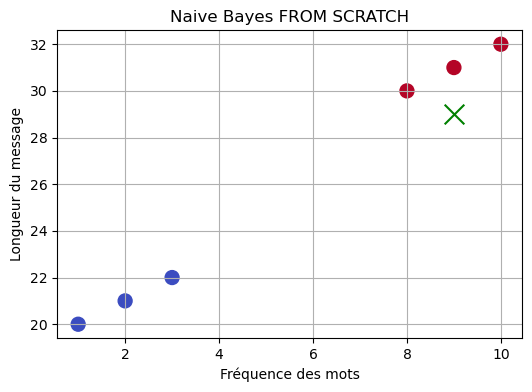

In [15]:
#Naive Bayes (apprentissage non supervise) From SCRATCG
import numpy as np
import matplotlib.pyplot as plt
# ================================
# 1. Dataset
# ================================

X = np.array([
    [1, 20],
    [2, 21],
    [3, 22],
    [8, 30],
    [9, 31],
    [10, 32]
])
# X représente les variables explicatives.

# Chaque ligne représente un message.

# colonne 1 :
# fréquence de certains mots.

# colonne 2 :
# longueur du message.

y = np.array([0, 0, 0, 1, 1, 1])
# y représente les classes :

# 0 = message normal
# 1 = message spam

# ================================
# 2. Séparation des classes
# ================================

X_class0 = X[y == 0]
# Sélection des données appartenant
# à la classe 0 (messages normaux).

X_class1 = X[y == 1]
# Sélection des données appartenant
# à la classe 1 (messages spam).

# ================================
# 3. Calcul des moyennes
# ================================

mean0 = np.mean(X_class0, axis=0)
# Moyenne des variables
# pour la classe 0.

mean1 = np.mean(X_class1, axis=0)
# Moyenne des variables
# pour la classe 1.

# ================================
# 4. Calcul des écarts-types
# ================================

std0 = np.std(X_class0, axis=0)
# Écart-type des variables
# pour la classe 0.

std1 = np.std(X_class1, axis=0)
# Écart-type des variables
# pour la classe 1.

# ================================
# 5. Fonction densité gaussienne
# ================================

def gaussian(x, mean, std):
    """
    Fonction de probabilité gaussienne.
    
    Elle calcule la probabilité
    qu’une valeur appartienne
    à une distribution normale.
    """

    exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))

    return (1 / (np.sqrt(2 * np.pi) * std)) * exponent

# ================================
# 6. Fonction de prédiction
# ================================

def predict(x):
    """
    Fonction de classification Naive Bayes.
    
    Elle calcule :
    - la probabilité pour la classe 0
    - la probabilité pour la classe 1
    
    Puis elle choisit
    la probabilité la plus grande.
    """

    # Probabilité classe 0
    prob0 = np.prod(gaussian(x, mean0, std0))

    # Probabilité classe 1
    prob1 = np.prod(gaussian(x, mean1, std1))

    # comparaison finale
    if prob0 > prob1:
        return 0
    else:
        return 1

# ================================
# 7. Test du modèle
# ================================

test = np.array([9, 29])
# Nouveau message à classifier.

# 9 = fréquence des mots
# 29 = longueur du message

prediction = predict(test)

print("Classe prédite :", prediction)

# ================================
# 8. Graphe
# ================================

plt.figure(figsize=(6,4))
# Création de la fenêtre graphique.

plt.scatter(X[:,0], X[:,1],
            c=y,
            cmap="coolwarm",
            s=100)
# Affichage des données réelles.

# X[:,0] :
# fréquence des mots.

# X[:,1] :
# longueur du message.

# c=y :
# couleur selon la classe.

# cmap :
# palette de couleurs.

plt.scatter(test[0], test[1],
            color="green",
            s=200,
            marker="x")
# Affichage du nouveau point à classifier.

# marker="x" :
# affiche une croix verte.

plt.xlabel("Fréquence des mots")
# Nom de l’axe horizontal.

plt.ylabel("Longueur du message")
# Nom de l’axe vertical.

plt.title("Naive Bayes FROM SCRATCH")
# Titre du graphique.

plt.grid(True)
# Ajout d’une grille.

plt.show()
# Affichage final du graphique.

Q-table initiale :
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]

Q-table finale :
[[0.04654032 0.08548602]
 [0.04951904 0.12532409]
 [0.01893858 0.04236872]
 [0.18470888 0.04307015]
 [0.77291323 0.5987824 ]]


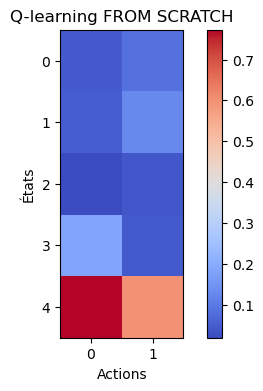

In [17]:
#Q-learning (apprentissage par renforcement) from scratch
import numpy as np
import matplotlib.pyplot as plt
# ================================
# 1. Création de la Q-table
# ================================

Q = np.zeros((5, 2))
# Création d’une matrice appelée Q-table.

# Cette table contient :

# - 5 états possibles
# - 2 actions possibles

# Chaque ligne représente un état.
#
# Chaque colonne représente une action.

# Q[state, action]
# contient la qualité estimée
# d’une action dans un état donné.

# Au début :
# toutes les valeurs sont initialisées à 0
# car l’agent ne possède encore
# aucune connaissance.

print("Q-table initiale :")
print(Q)

# ================================
# 2. Paramètres du modèle
# ================================

learning_rate = 0.1
# Taux d’apprentissage.

# Ce paramètre contrôle
# la vitesse d’apprentissage.

# Petite valeur :
# apprentissage lent mais stable.

# Grande valeur :
# apprentissage rapide mais parfois instable.

gamma = 0.9
# Facteur de réduction (discount factor).

# Il mesure l’importance
# des récompenses futures.

# gamma proche de 1 :
# l’agent pense au long terme.

episodes = 100
# Nombre total d’épisodes.

# Chaque épisode représente
# une nouvelle tentative
# d’apprentissage.

# ================================
# 3. Phase d’apprentissage
# ================================

for episode in range(episodes):

    # ----------------------------
    # Choix aléatoire d’un état
    # ----------------------------

    state = np.random.randint(0, 5)
    # Génération aléatoire
    # d’un état entre 0 et 4.

    # ----------------------------
    # Choix aléatoire d’une action
    # ----------------------------

    action = np.random.randint(0, 2)
    # Génération aléatoire
    # d’une action :
    
    # 0 ou 1.

    # ----------------------------
    # Système de récompense
    # ----------------------------

    reward = 1 if state == 4 else 0
    # Si l’agent atteint l’état 4 :
    # récompense positive = 1.
    
    # Sinon :
    # récompense = 0.

    # ----------------------------
    # Simulation de l’état suivant
    # ----------------------------

    next_state = np.random.randint(0, 5)
    # Simulation d’un nouvel état
    # après l’action choisie.

    # ============================
    # Équation de Q-learning
    # ============================

    Q[state, action] = Q[state, action] + learning_rate * (
        reward +
        gamma * np.max(Q[next_state]) -
        Q[state, action]
    )

    # Cette formule permet de mettre à jour
    # la connaissance de l’agent.

    # reward :
    # récompense immédiate.
    
    # gamma * max(Q[next_state]) :
    # meilleure récompense future possible.
    
    # Q[state, action] :
    # ancienne valeur connue.
    
    # L’objectif est d’améliorer progressivement
    # les décisions prises par l’agent.

# ================================
# 4. Résultat final
# ================================

print("\nQ-table finale :")
print(Q)

# Les grandes valeurs indiquent
# les meilleures actions à choisir
# dans chaque état.

# ================================
# 5. Graphe de la Q-table
# ================================

plt.figure(figsize=(6,4))
# Création d’une figure graphique.

# figsize définit la taille du graphique.

plt.imshow(Q, cmap="coolwarm")
# Affichage de la Q-table sous forme
# de carte de couleurs.

# Chaque case représente une valeur Q.

# Couleurs froides :
# petites valeurs.

# Couleurs chaudes :
# grandes valeurs.

plt.colorbar()
# Ajout d’une barre de couleurs
# pour interpréter les valeurs.

plt.xlabel("Actions")
# Axe horizontal :
# actions possibles.

plt.ylabel("États")
# Axe vertical :
# états possibles.

plt.title("Q-learning FROM SCRATCH")
# Titre du graphique.

plt.show()
# Affichage final du graphique.